In [1]:
import os
import cv2
import random
import time
import itertools
import optuna
import gc
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from skimage.feature import hog, local_binary_pattern, graycomatrix, graycoprops
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

[0] LOADING PATHS...
[1] Extracting features...


100%|██████████| 1630/1630 [01:36<00:00, 16.81it/s]



 STARTING EXPERIMENT
 1. Calc Default CV | 2. Tune Params & Weight | 3. Final Test & Latency

############################################################
 [1/31] COMBO: Color
############################################################
   [Baseline] Default CV F1: 0.8609
[!] Kỷ lục mới! F1: 0.8838. Đang lưu mô hình...
   >>> Result: Def_CV=0.8609 | Tuned_CV=0.8609 | Test_F1=0.8838
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.8869    0.8765    0.8817       170
        rain     0.7818    0.8190    0.8000       105
       shine     1.0000    0.9412    0.9697        51

    accuracy                         0.8681       326
   macro avg     0.8896    0.8789    0.8838       326
weighted avg     0.8708    0.8681    0.8691       326



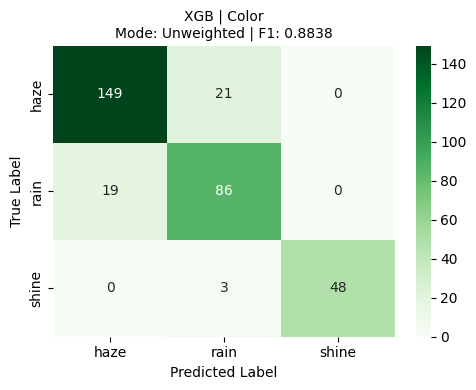

--------------------------------------------------

############################################################
 [2/31] COMBO: Sobel
############################################################
   [Baseline] Default CV F1: 0.6956
   >>> Result: Def_CV=0.6956 | Tuned_CV=0.6970 | Test_F1=0.7298
   >>> Latency: 0.00 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9216    0.8294    0.8731       170
        rain     0.8723    0.7810    0.8241       105
       shine     0.4051    0.6275    0.4923        51

    accuracy                         0.7822       326
   macro avg     0.7330    0.7459    0.7298       326
weighted avg     0.8249    0.7822    0.7977       326



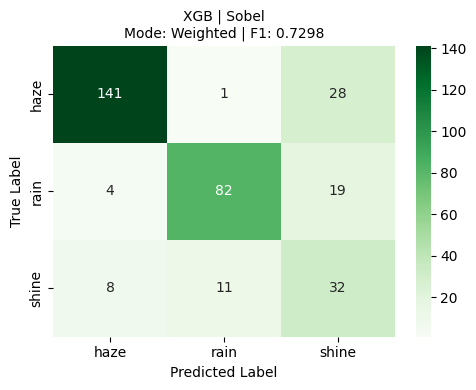

--------------------------------------------------

############################################################
 [3/31] COMBO: LBP
############################################################
   [Baseline] Default CV F1: 0.8610
   >>> Result: Def_CV=0.8610 | Tuned_CV=0.8736 | Test_F1=0.8673
   >>> Latency: 0.03 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9277    0.9059    0.9167       170
        rain     0.8348    0.9143    0.8727       105
       shine     0.8667    0.7647    0.8125        51

    accuracy                         0.8865       326
   macro avg     0.8764    0.8616    0.8673       326
weighted avg     0.8882    0.8865    0.8862       326



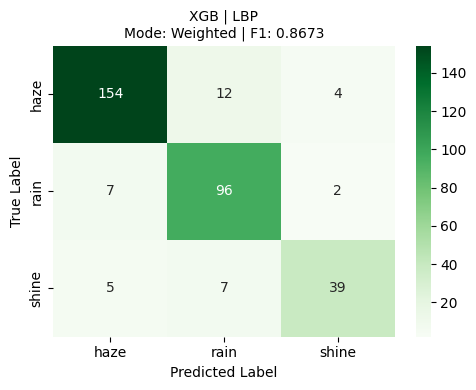

--------------------------------------------------

############################################################
 [4/31] COMBO: HOG
############################################################
   [Baseline] Default CV F1: 0.5820
   >>> Result: Def_CV=0.5820 | Tuned_CV=0.6174 | Test_F1=0.5997
   >>> Latency: 0.00 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.8394    0.6765    0.7492       170
        rain     0.6963    0.8952    0.7833       105
       shine     0.2593    0.2745    0.2667        51

    accuracy                         0.6840       326
   macro avg     0.5983    0.6154    0.5997       326
weighted avg     0.7026    0.6840    0.6847       326



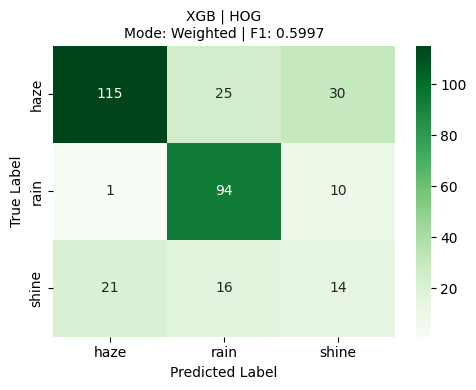

--------------------------------------------------

############################################################
 [5/31] COMBO: GLCM
############################################################
   [Baseline] Default CV F1: 0.7962
   >>> Result: Def_CV=0.7962 | Tuned_CV=0.8114 | Test_F1=0.8268
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.8960    0.9118    0.9038       170
        rain     0.8879    0.9048    0.8962       105
       shine     0.7174    0.6471    0.6804        51

    accuracy                         0.8681       326
   macro avg     0.8337    0.8212    0.8268       326
weighted avg     0.8654    0.8681    0.8664       326



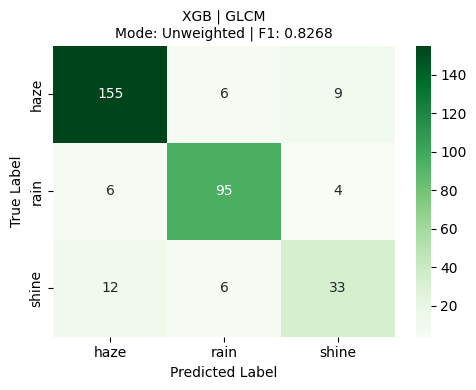

--------------------------------------------------

############################################################
 [6/31] COMBO: Color + Sobel
############################################################
   [Baseline] Default CV F1: 0.9140
[!] Kỷ lục mới! F1: 0.9413. Đang lưu mô hình...
   >>> Result: Def_CV=0.9140 | Tuned_CV=0.9181 | Test_F1=0.9413
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9816    0.9412    0.9610       170
        rain     0.8929    0.9524    0.9217       105
       shine     0.9412    0.9412    0.9412        51

    accuracy                         0.9448       326
   macro avg     0.9385    0.9449    0.9413       326
weighted avg     0.9467    0.9448    0.9452       326



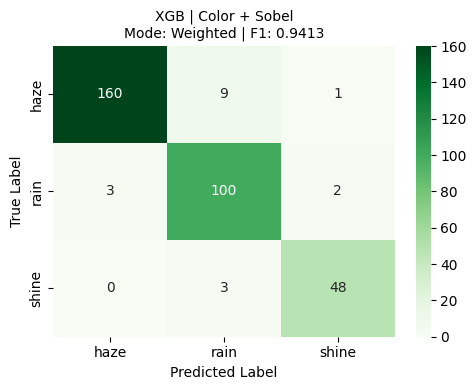

--------------------------------------------------

############################################################
 [7/31] COMBO: Color + LBP
############################################################
   [Baseline] Default CV F1: 0.9313
[!] Kỷ lục mới! F1: 0.9435. Đang lưu mô hình...
   >>> Result: Def_CV=0.9313 | Tuned_CV=0.9363 | Test_F1=0.9435
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9586    0.9529    0.9558       170
        rain     0.9083    0.9429    0.9252       105
       shine     0.9792    0.9216    0.9495        51

    accuracy                         0.9448       326
   macro avg     0.9487    0.9391    0.9435       326
weighted avg     0.9456    0.9448    0.9449       326



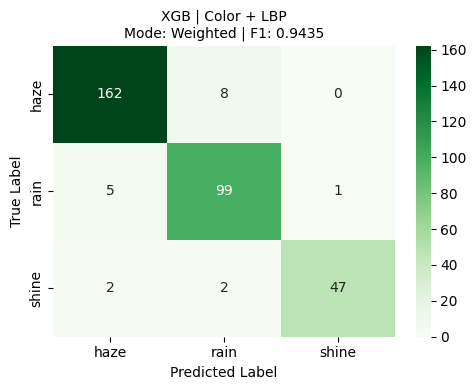

--------------------------------------------------

############################################################
 [8/31] COMBO: Color + HOG
############################################################
   [Baseline] Default CV F1: 0.8952
   >>> Result: Def_CV=0.8952 | Tuned_CV=0.9068 | Test_F1=0.9209
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9249    0.9412    0.9329       170
        rain     0.8868    0.8952    0.8910       105
       shine     0.9787    0.9020    0.9388        51

    accuracy                         0.9202       326
   macro avg     0.9301    0.9128    0.9209       326
weighted avg     0.9210    0.9202    0.9203       326



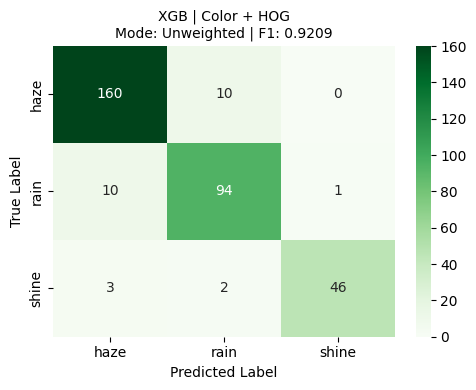

--------------------------------------------------

############################################################
 [9/31] COMBO: Color + GLCM
############################################################
   [Baseline] Default CV F1: 0.9215
[!] Kỷ lục mới! F1: 0.9487. Đang lưu mô hình...
   >>> Result: Def_CV=0.9215 | Tuned_CV=0.9288 | Test_F1=0.9487
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9701    0.9529    0.9614       170
        rain     0.9099    0.9619    0.9352       105
       shine     0.9792    0.9216    0.9495        51

    accuracy                         0.9509       326
   macro avg     0.9530    0.9455    0.9487       326
weighted avg     0.9521    0.9509    0.9511       326



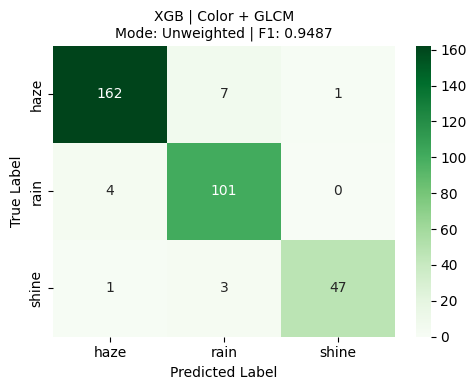

--------------------------------------------------

############################################################
 [10/31] COMBO: Sobel + LBP
############################################################
   [Baseline] Default CV F1: 0.8830
   >>> Result: Def_CV=0.8830 | Tuned_CV=0.8830 | Test_F1=0.8842
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9253    0.9471    0.9360       170
        rain     0.8750    0.9333    0.9032       105
       shine     0.9250    0.7255    0.8132        51

    accuracy                         0.9080       326
   macro avg     0.9084    0.8686    0.8842       326
weighted avg     0.9090    0.9080    0.9063       326



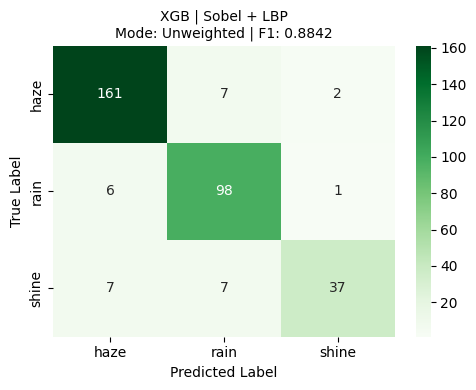

--------------------------------------------------

############################################################
 [11/31] COMBO: Sobel + HOG
############################################################
   [Baseline] Default CV F1: 0.7605
   >>> Result: Def_CV=0.7605 | Tuned_CV=0.7827 | Test_F1=0.8192
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9222    0.9059    0.9139       170
        rain     0.8636    0.9048    0.8837       105
       shine     0.6735    0.6471    0.6600        51

    accuracy                         0.8650       326
   macro avg     0.8198    0.8192    0.8192       326
weighted avg     0.8644    0.8650    0.8645       326



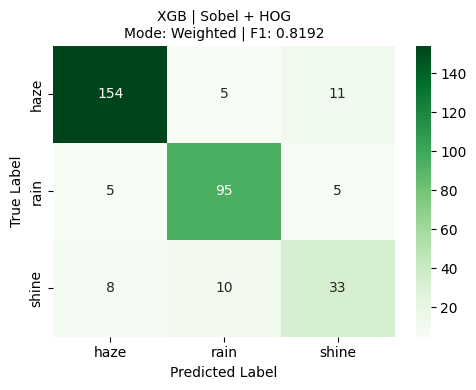

--------------------------------------------------

############################################################
 [12/31] COMBO: Sobel + GLCM
############################################################
   [Baseline] Default CV F1: 0.8550
   >>> Result: Def_CV=0.8550 | Tuned_CV=0.8562 | Test_F1=0.8718
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9689    0.9176    0.9426       170
        rain     0.8899    0.9238    0.9065       105
       shine     0.7321    0.8039    0.7664        51

    accuracy                         0.9018       326
   macro avg     0.8637    0.8818    0.8718       326
weighted avg     0.9064    0.9018    0.9034       326



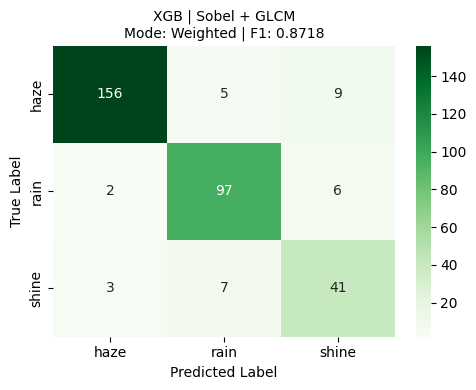

--------------------------------------------------

############################################################
 [13/31] COMBO: LBP + HOG
############################################################
   [Baseline] Default CV F1: 0.8758
   >>> Result: Def_CV=0.8758 | Tuned_CV=0.8787 | Test_F1=0.8522
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9387    0.9000    0.9189       170
        rain     0.8049    0.9429    0.8684       105
       shine     0.8750    0.6863    0.7692        51

    accuracy                         0.8804       326
   macro avg     0.8728    0.8430    0.8522       326
weighted avg     0.8856    0.8804    0.8792       326



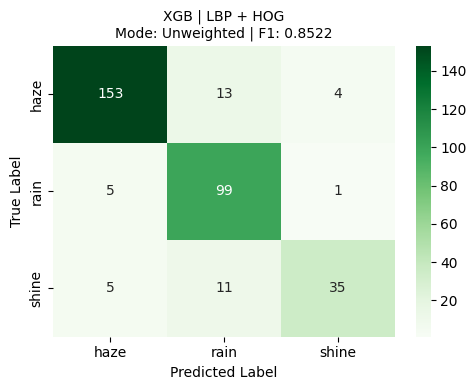

--------------------------------------------------

############################################################
 [14/31] COMBO: LBP + GLCM
############################################################
   [Baseline] Default CV F1: 0.9009
   >>> Result: Def_CV=0.9009 | Tuned_CV=0.9026 | Test_F1=0.9126
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9529    0.9529    0.9529       170
        rain     0.8929    0.9524    0.9217       105
       shine     0.9318    0.8039    0.8632        51

    accuracy                         0.9294       326
   macro avg     0.9259    0.9031    0.9126       326
weighted avg     0.9303    0.9294    0.9288       326



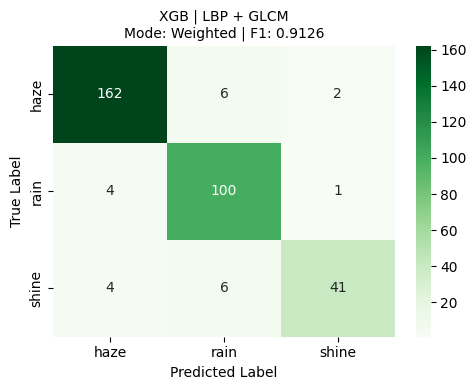

--------------------------------------------------

############################################################
 [15/31] COMBO: HOG + GLCM
############################################################
   [Baseline] Default CV F1: 0.8241
   >>> Result: Def_CV=0.8241 | Tuned_CV=0.8302 | Test_F1=0.8058
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9112    0.9059    0.9086       170
        rain     0.8261    0.9048    0.8636       105
       shine     0.7143    0.5882    0.6452        51

    accuracy                         0.8558       326
   macro avg     0.8172    0.7996    0.8058       326
weighted avg     0.8530    0.8558    0.8529       326



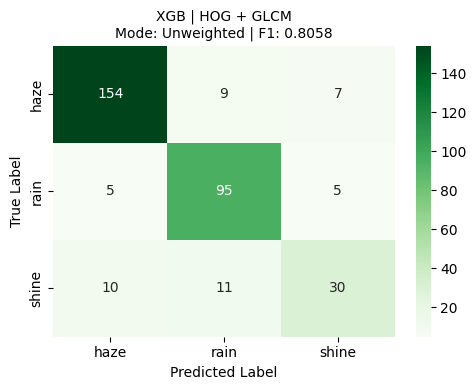

--------------------------------------------------

############################################################
 [16/31] COMBO: Color + Sobel + LBP
############################################################
   [Baseline] Default CV F1: 0.9275
   >>> Result: Def_CV=0.9275 | Tuned_CV=0.9380 | Test_F1=0.9443
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9588    0.9588    0.9588       170
        rain     0.9252    0.9429    0.9340       105
       shine     0.9592    0.9216    0.9400        51

    accuracy                         0.9479       326
   macro avg     0.9477    0.9411    0.9443       326
weighted avg     0.9481    0.9479    0.9479       326



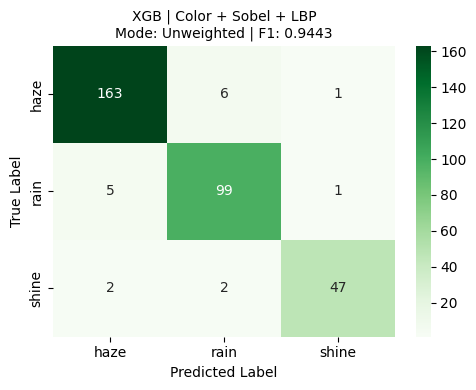

--------------------------------------------------

############################################################
 [17/31] COMBO: Color + Sobel + HOG
############################################################
   [Baseline] Default CV F1: 0.9205
[!] Kỷ lục mới! F1: 0.9576. Đang lưu mô hình...
   >>> Result: Def_CV=0.9205 | Tuned_CV=0.9301 | Test_F1=0.9576
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9820    0.9647    0.9733       170
        rain     0.9182    0.9619    0.9395       105
       shine     0.9796    0.9412    0.9600        51

    accuracy                         0.9601       326
   macro avg     0.9599    0.9559    0.9576       326
weighted avg     0.9611    0.9601    0.9603       326



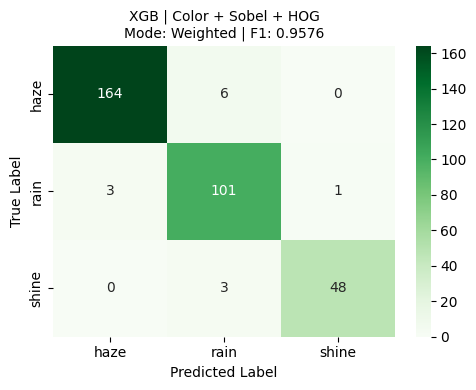

--------------------------------------------------

############################################################
 [18/31] COMBO: Color + Sobel + GLCM
############################################################
   [Baseline] Default CV F1: 0.9233
   >>> Result: Def_CV=0.9233 | Tuned_CV=0.9315 | Test_F1=0.9467
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9645    0.9588    0.9617       170
        rain     0.9182    0.9619    0.9395       105
       shine     0.9787    0.9020    0.9388        51

    accuracy                         0.9509       326
   macro avg     0.9538    0.9409    0.9467       326
weighted avg     0.9518    0.9509    0.9509       326



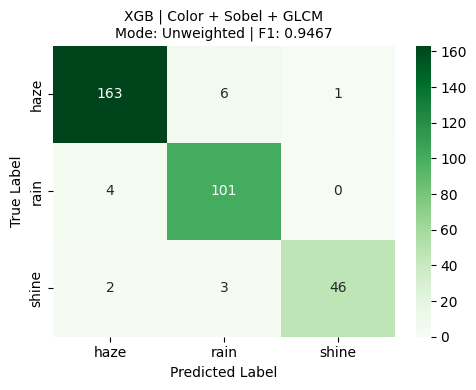

--------------------------------------------------

############################################################
 [19/31] COMBO: Color + LBP + HOG
############################################################
   [Baseline] Default CV F1: 0.9292
   >>> Result: Def_CV=0.9292 | Tuned_CV=0.9326 | Test_F1=0.9317
   >>> Latency: 0.02 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9477    0.9588    0.9532       170
        rain     0.9083    0.9429    0.9252       105
       shine     0.9778    0.8627    0.9167        51

    accuracy                         0.9387       326
   macro avg     0.9446    0.9215    0.9317       326
weighted avg     0.9397    0.9387    0.9385       326



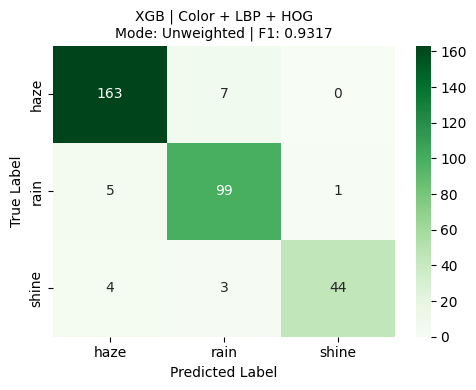

--------------------------------------------------

############################################################
 [20/31] COMBO: Color + LBP + GLCM
############################################################
   [Baseline] Default CV F1: 0.9345
   >>> Result: Def_CV=0.9345 | Tuned_CV=0.9423 | Test_F1=0.9462
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9647    0.9647    0.9647       170
        rain     0.9252    0.9429    0.9340       105
       shine     0.9592    0.9216    0.9400        51

    accuracy                         0.9509       326
   macro avg     0.9497    0.9430    0.9462       326
weighted avg     0.9511    0.9509    0.9509       326



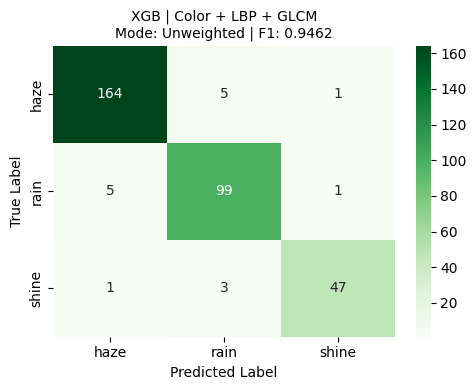

--------------------------------------------------

############################################################
 [21/31] COMBO: Color + HOG + GLCM
############################################################
   [Baseline] Default CV F1: 0.9256
[!] Kỷ lục mới! F1: 0.9579. Đang lưu mô hình...
   >>> Result: Def_CV=0.9256 | Tuned_CV=0.9325 | Test_F1=0.9579
   >>> Latency: 0.00 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9706    0.9706    0.9706       170
        rain     0.9266    0.9619    0.9439       105
       shine     1.0000    0.9216    0.9592        51

    accuracy                         0.9601       326
   macro avg     0.9657    0.9514    0.9579       326
weighted avg     0.9610    0.9601    0.9602       326



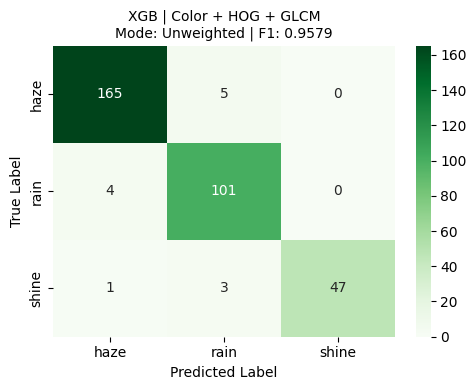

--------------------------------------------------

############################################################
 [22/31] COMBO: Sobel + LBP + HOG
############################################################
   [Baseline] Default CV F1: 0.8823
   >>> Result: Def_CV=0.8823 | Tuned_CV=0.8941 | Test_F1=0.8572
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9244    0.9353    0.9298       170
        rain     0.8462    0.9429    0.8919       105
       shine     0.8919    0.6471    0.7500        51

    accuracy                         0.8926       326
   macro avg     0.8875    0.8417    0.8572       326
weighted avg     0.8941    0.8926    0.8895       326



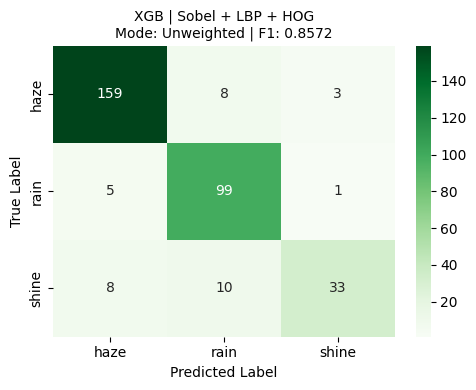

--------------------------------------------------

############################################################
 [23/31] COMBO: Sobel + LBP + GLCM
############################################################
   [Baseline] Default CV F1: 0.8967
   >>> Result: Def_CV=0.8967 | Tuned_CV=0.9029 | Test_F1=0.9099
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9527    0.9471    0.9499       170
        rain     0.8818    0.9238    0.9023       105
       shine     0.9149    0.8431    0.8776        51

    accuracy                         0.9233       326
   macro avg     0.9165    0.9047    0.9099       326
weighted avg     0.9239    0.9233    0.9232       326



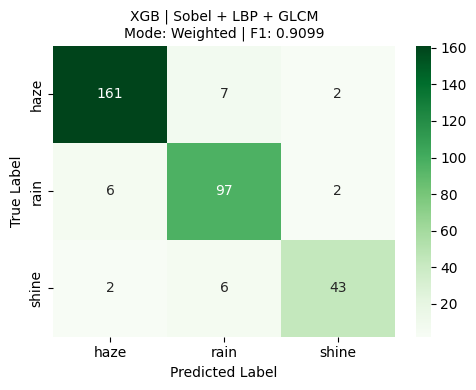

--------------------------------------------------

############################################################
 [24/31] COMBO: Sobel + HOG + GLCM
############################################################
   [Baseline] Default CV F1: 0.8487
   >>> Result: Def_CV=0.8487 | Tuned_CV=0.8528 | Test_F1=0.8581
   >>> Latency: 0.00 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9290    0.9235    0.9263       170
        rain     0.8727    0.9143    0.8930       105
       shine     0.7872    0.7255    0.7551        51

    accuracy                         0.8896       326
   macro avg     0.8630    0.8544    0.8581       326
weighted avg     0.8887    0.8896    0.8888       326



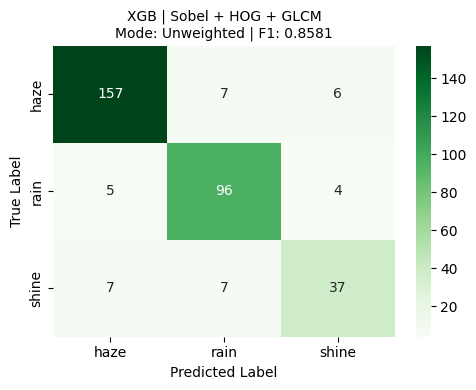

--------------------------------------------------

############################################################
 [25/31] COMBO: LBP + HOG + GLCM
############################################################
   [Baseline] Default CV F1: 0.8974
   >>> Result: Def_CV=0.8974 | Tuned_CV=0.9081 | Test_F1=0.8991
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9471    0.9471    0.9471       170
        rain     0.8673    0.9333    0.8991       105
       shine     0.9302    0.7843    0.8511        51

    accuracy                         0.9172       326
   macro avg     0.9148    0.8882    0.8991       326
weighted avg     0.9187    0.9172    0.9166       326



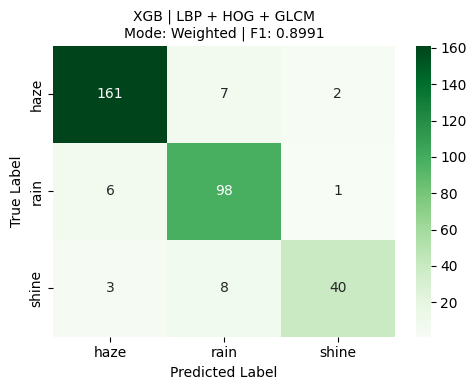

--------------------------------------------------

############################################################
 [26/31] COMBO: Color + Sobel + LBP + HOG
############################################################
   [Baseline] Default CV F1: 0.9271
   >>> Result: Def_CV=0.9271 | Tuned_CV=0.9331 | Test_F1=0.9439
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9593    0.9706    0.9649       170
        rain     0.9259    0.9524    0.9390       105
       shine     0.9783    0.8824    0.9278        51

    accuracy                         0.9509       326
   macro avg     0.9545    0.9351    0.9439       326
weighted avg     0.9515    0.9509    0.9508       326



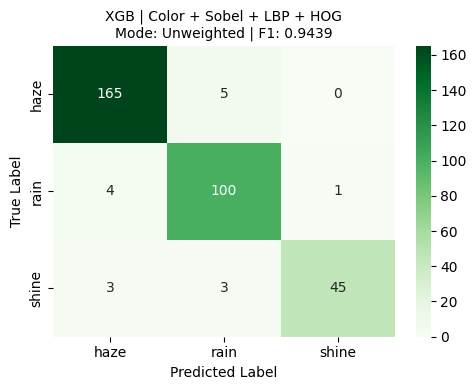

--------------------------------------------------

############################################################
 [27/31] COMBO: Color + Sobel + LBP + GLCM
############################################################
   [Baseline] Default CV F1: 0.9346
   >>> Result: Def_CV=0.9346 | Tuned_CV=0.9429 | Test_F1=0.9409
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9540    0.9765    0.9651       170
        rain     0.9327    0.9238    0.9282       105
       shine     0.9583    0.9020    0.9293        51

    accuracy                         0.9479       326
   macro avg     0.9483    0.9341    0.9409       326
weighted avg     0.9478    0.9479    0.9476       326



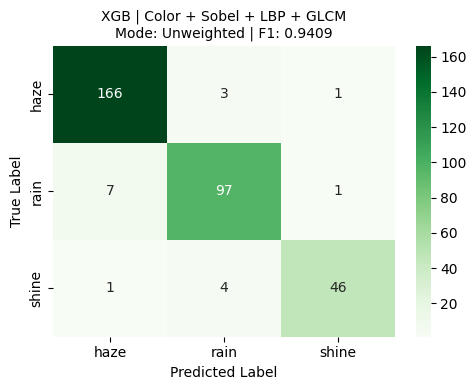

--------------------------------------------------

############################################################
 [28/31] COMBO: Color + Sobel + HOG + GLCM
############################################################
   [Baseline] Default CV F1: 0.9269
   >>> Result: Def_CV=0.9269 | Tuned_CV=0.9304 | Test_F1=0.9438
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9704    0.9647    0.9676       170
        rain     0.9174    0.9524    0.9346       105
       shine     0.9583    0.9020    0.9293        51

    accuracy                         0.9509       326
   macro avg     0.9487    0.9397    0.9438       326
weighted avg     0.9515    0.9509    0.9509       326



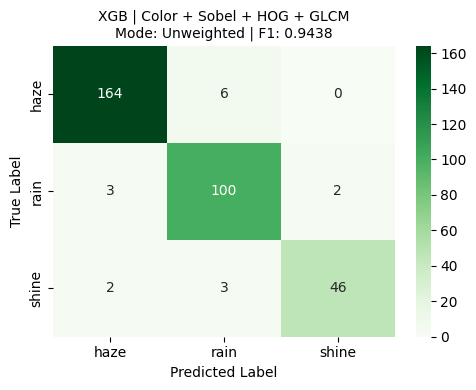

--------------------------------------------------

############################################################
 [29/31] COMBO: Color + LBP + HOG + GLCM
############################################################
   [Baseline] Default CV F1: 0.9357
   >>> Result: Def_CV=0.9357 | Tuned_CV=0.9429 | Test_F1=0.9483
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9762    0.9647    0.9704       170
        rain     0.9174    0.9524    0.9346       105
       shine     0.9592    0.9216    0.9400        51

    accuracy                         0.9540       326
   macro avg     0.9509    0.9462    0.9483       326
weighted avg     0.9546    0.9540    0.9541       326



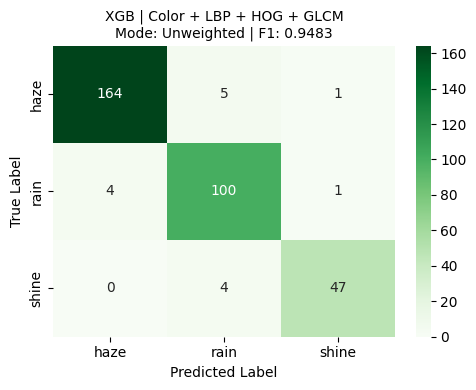

--------------------------------------------------

############################################################
 [30/31] COMBO: Sobel + LBP + HOG + GLCM
############################################################
   [Baseline] Default CV F1: 0.8932
   >>> Result: Def_CV=0.8932 | Tuned_CV=0.9027 | Test_F1=0.9045
   >>> Latency: 0.01 ms/img | Mode: Weighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9639    0.9412    0.9524       170
        rain     0.8632    0.9619    0.9099       105
       shine     0.9302    0.7843    0.8511        51

    accuracy                         0.9233       326
   macro avg     0.9191    0.8958    0.9045       326
weighted avg     0.9262    0.9233    0.9229       326



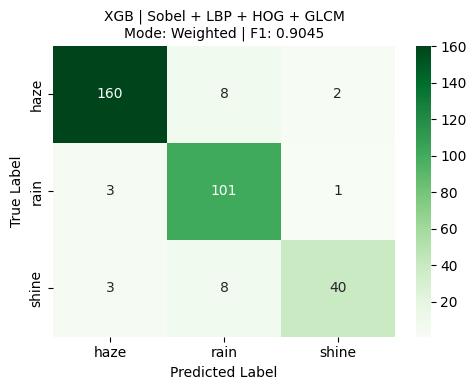

--------------------------------------------------

############################################################
 [31/31] COMBO: Color + Sobel + LBP + HOG + GLCM
############################################################
   [Baseline] Default CV F1: 0.9344
   >>> Result: Def_CV=0.9344 | Tuned_CV=0.9420 | Test_F1=0.9413
   >>> Latency: 0.01 ms/img | Mode: Unweighted
--------------------------------------------------
              precision    recall  f1-score   support

        haze     0.9702    0.9588    0.9645       170
        rain     0.9091    0.9524    0.9302       105
       shine     0.9583    0.9020    0.9293        51

    accuracy                         0.9479       326
   macro avg     0.9459    0.9377    0.9413       326
weighted avg     0.9487    0.9479    0.9480       326



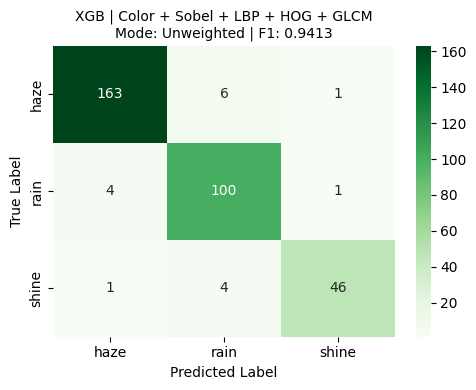

--------------------------------------------------

>>> RESULTS SUMMARY:
               Combination  Default CV F1  Tuned CV F1  Test F1 (Final)  Latency (ms/img)
        Color + HOG + GLCM         0.9256       0.9325           0.9579            0.0045
       Color + Sobel + HOG         0.9205       0.9301           0.9576            0.0132
              Color + GLCM         0.9215       0.9288           0.9487            0.0075
  Color + LBP + HOG + GLCM         0.9357       0.9429           0.9483            0.0099
      Color + Sobel + GLCM         0.9233       0.9315           0.9467            0.0081
        Color + LBP + GLCM         0.9345       0.9423           0.9462            0.0069
       Color + Sobel + LBP         0.9275       0.9380           0.9443            0.0054
 Color + Sobel + LBP + HOG         0.9271       0.9331           0.9439            0.0108
Color + Sobel + HOG + GLCM         0.9269       0.9304           0.9438            0.0075
               Color + LBP 

In [2]:
# Tắt log của optuna và định dạng hiển thị số thập phân của pandas
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# ===================================================================
# 0. SETUP & LOAD DATA
# ===================================================================
# Thiết lập seed ngẫu nhiên, đảm bảo tính tái lập và ổn định của kết quả
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
SEED = 42
seed_everything(SEED)

# Đường dẫn đến 3 thư mục chứa hình ảnh tương ứng với 3 nhãn thời tiết trên Kaggle
DATA_SOURCES = {
    'haze': '/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/fogsmog',
    'rain': '/kaggle/input/datasets/jehanbhathena/weather-dataset/dataset/rain',
    'shine': '/kaggle/input/datasets/pratik2901/multiclass-weather-dataset/Multi-class Weather Dataset/Shine'
}
# Kích thước ảnh chuẩn hóa và tham số HOG
IMG_SIZE = 256
HOG_PPC = 16

# Duyệt qua từng nhãn và đường dẫn, thu thập tất cả các ảnh và nhãn tương ứng
print("[0] LOADING PATHS...")
img_paths, labels_raw = [], []
for label, path in DATA_SOURCES.items():
    if os.path.exists(path):
        files = sorted([os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(('.jpg','.png','.jpeg'))])
        img_paths.extend(files)
        labels_raw.extend([label] * len(files))

# Mã hóa nhãn từ dạng chuỗi sang số nguyên để mô hình có thể xử lý
le = LabelEncoder()
y_encoded = le.fit_transform(labels_raw)
class_names = le.classes_

# ===================================================================
# 1. FEATURE EXTRACTION
# ===================================================================
# Chuyển ảnh sang không gian màu HSV, tính trung bình (mean) và độ lệch chuẩn (std) của từng kênh
def get_color_stats(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    return [np.mean(hsv[:,:,i]) for i in range(3)] + [np.std(hsv[:,:,i]) for i in range(3)]

# Tính toán ma trận Sobel để lấy đặc trưng biên (edges), sau đó tính trung bình và phương sai của độ lớn biên
def get_sobel_stats(gray):
    sx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    return [np.mean(mag), np.var(mag)]

# Tính toán LBP để mô tả kết cấu (texture) cục bộ của bức ảnh
def get_lbp_hist(gray):
    lbp = local_binary_pattern(gray, P=8, R=1, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=10, range=(0, 10))
    hist = hist.astype("float"); return hist / (hist.sum() + 1e-7)

# Tính toán HOG để trích xuất hình dạng và đường bao của các vật thể trong ảnh
def get_hog_stats(gray):
    hog_v = hog(gray, orientations=12, pixels_per_cell=(HOG_PPC, HOG_PPC), cells_per_block=(2,2), visualize=False, feature_vector=True)
    return [np.mean(hog_v), np.std(hog_v), np.max(hog_v)]

# Phân tích GLCM để trích xuất các đặc trưng về kết cấu như độ tương phản, tương quan, năng lượng và đồng nhất
def get_glcm_stats(gray):
    glcm = graycomatrix(gray, distances=[1], angles=[0, np.pi/2], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast').flatten()
    correlation = graycoprops(glcm, 'correlation').flatten()
    energy = graycoprops(glcm, 'energy').flatten()
    homogeneity = graycoprops(glcm, 'homogeneity').flatten()
    return np.concatenate([contrast, correlation, energy, homogeneity])

# Hàm tổng hợp để trích xuất tất cả các đặc trưng đã định nghĩa ở trên cho mỗi ảnh trong danh sách đường dẫn
def extract_all(paths):
    l_c, l_s, l_l, l_h, l_glcm = [], [], [], [], []
    print("[1] Extracting features...")
    for path in tqdm(paths):
        img = cv2.imread(path); img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        l_c.append(get_color_stats(img))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        l_s.append(get_sobel_stats(gray)); l_l.append(get_lbp_hist(gray))
        l_h.append(get_hog_stats(gray)); l_glcm.append(get_glcm_stats(gray))
    return {'Color': np.array(l_c), 'Sobel': np.array(l_s), 'LBP': np.array(l_l), 'HOG': np.array(l_h), 'GLCM': np.array(l_glcm)}

all_features = extract_all(img_paths)

# Chia dữ liệu thành tập huấn luyện (train: 80%) và kiểm tra (test: 20%)
indices = np.arange(len(img_paths))
X_train_idx, X_test_idx, y_train, y_test = train_test_split(indices, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded)

# Thiết lập chiến lược kiểm tra chéo (Cross-Validation) với 5 folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Tạo tất cả các tổ hợp có thể của 5 loại đặc trưng để thử nghiệm (tổng cộng 31 tổ hợp)
base_features = ['Color', 'Sobel', 'LBP', 'HOG', 'GLCM']
all_combinations = []
for r in range(1, len(base_features) + 1):
    for combo in itertools.combinations(base_features, r):
        all_combinations.append({'name': " + ".join(combo), 'components': list(combo)})

# Vẽ ma trận nhầm lẫn (confusion matrix) dưới dạng heatmap để trực quan hóa hiệu suất của mô hình trên tập kiểm tra
def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=10); plt.ylabel('True Label'); plt.xlabel('Predicted Label'); plt.tight_layout(); plt.show()

# ===================================================================
# 2. MAIN LOOP: XGBOOST (DEFAULT vs TUNED + WEIGHT DECISION)
# ===================================================================
results = []
checkpoint_file = 'xgb_smart_tuning_results.csv'

# Lưu trạng thái mô hình tốt nhất
best_overall_f1 = 0.0
best_model_info = {}

print("\n" + "="*80)
print(f" STARTING EXPERIMENT")
print(f" 1. Calc Default CV | 2. Tune Params & Weight | 3. Final Test & Latency")
print("="*80)

# Duyệt qua từng tổ hợp đặc trưng và thực hiện 3 giai đoạn
for idx, combo in enumerate(all_combinations):
    # Tên tổ hợp và các thành phần đặc trưng
    combo_name = combo['name']
    comps = combo['components']
    
    # Dữ liệu đặc trưng cho tập Train và Test dựa trên các thành phần đã chọn
    X_train_curr = np.hstack([all_features[c][X_train_idx] for c in comps])
    X_test_curr  = np.hstack([all_features[c][X_test_idx] for c in comps])
    
    print(f"\n{'#'*60}")
    print(f" [{idx+1}/31] COMBO: {combo_name}")
    print(f"{'#'*60}")
    
    # --- PHASE A: CALCULATE DEFAULT CV SCORE (BASELINE) ---
    # Sử dụng XGBoost với tham số mặc định để có điểm chuẩn (baseline) trước khi tiến hành tuning
    xgb_default = XGBClassifier(eval_metric='mlogloss', random_state=SEED, n_jobs=-1)
    
    # Tạo pipeline để chuẩn hóa dữ liệu trước khi đưa vào mô hình
    pipe_default = Pipeline([('scaler', StandardScaler()), ('clf', xgb_default)])
    
    # Đo CV trên tập Train
    scores_default = cross_val_score(pipe_default, X_train_curr, y_train, cv=cv_strategy, scoring='f1_macro', n_jobs=-1)
    default_cv_f1 = scores_default.mean()
    print(f"   [Baseline] Default CV F1: {default_cv_f1:.4f}")

    # --- PHASE B: OPTUNA TUNING (PARAMS + WEIGHT) ---
    def objective(trial):
        # 1. Điều chỉnh siêu tham số của XGBoost
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
            'gamma': trial.suggest_float('gamma', 0, 5),
            'eval_metric': 'mlogloss', 'random_state': SEED, 'n_jobs': -1
        }
        
        # 2. Chiến lược Tune Balancing (Có dùng Weight hay không?)
        use_balancing = trial.suggest_categorical('use_balancing', [True, False])
        
        # 3. Vòng lặp CV để đánh giá hiệu suất của mô hình với tham số hiện tại
        cv_scores = []
        for train_idx_cv, val_idx_cv in cv_strategy.split(X_train_curr, y_train):
            # Lấy dữ liệu thô cho mỗi Fold
            X_tr_fold = X_train_curr[train_idx_cv]
            X_val_fold = X_train_curr[val_idx_cv]
            
            y_tr_fold = y_train[train_idx_cv]
            y_val_fold = y_train[val_idx_cv]
            
            sample_w = None
            if use_balancing:
                sample_w = compute_sample_weight('balanced', y_tr_fold)
            
            clf = XGBClassifier(**params)
            clf.fit(X_tr_fold, y_tr_fold, sample_weight=sample_w)
            
            preds = clf.predict(X_val_fold)
            cv_scores.append(f1_score(y_val_fold, preds, average='macro'))
            
        return np.mean(cv_scores)

    study = optuna.create_study(direction='maximize')
    
    # Thêm tham số mặc định vào Enqueue (Để đảm bảo Tuned >= Default)
    study.enqueue_trial({
        'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.3, 'subsample': 1.0, 
        'colsample_bytree': 1.0, 'min_child_weight': 1, 'gamma': 0, 'use_balancing': False
    })
    
    # Bắt đầu quá trình tối ưu hóa với Optuna, tìm kiếm tham số tốt nhất dựa trên điểm CV F1
    study.optimize(objective, n_trials=50) 
    
    # Lấy tham số tốt nhất và điểm CV tương ứng sau khi tuning
    best_params = study.best_params
    tuned_cv_f1 = study.best_value
    
    # --- PHASE C: FINAL TRAIN & TEST PREDICT (MEASURE LATENCY) ---
    # Sử dụng bộ siêu tham số tốt nhất (best_params) vừa tìm được
    use_balancing_final = best_params.pop('use_balancing')
    final_xgb = XGBClassifier(**best_params, eval_metric='mlogloss', random_state=SEED, n_jobs=-1)
    
    final_weights = None
    if use_balancing_final:
        final_weights = compute_sample_weight('balanced', y_train)
    
    # Train
    final_xgb.fit(X_train_curr, y_train, sample_weight=final_weights)
    
    # Đo thời gian dự đoán trên tập Test để tính toán độ trễ (latency)
    t0 = time.time()
    y_test_pred = final_xgb.predict(X_test_curr)
    t1 = time.time()
    
    # Tính độ trễ Latency (ms per image)
    latency_ms = ((t1 - t0) * 1000) / len(X_test_curr)
    
    # Tính điểm F1 trên tập Test với mô hình đã được tối ưu hóa
    test_f1 = f1_score(y_test, y_test_pred, average='macro')
    
    # Lưu mô hình tốt nhất
    if test_f1 > best_overall_f1:
        best_overall_f1 = test_f1
        best_model_info = {
            'combination': combo_name,
            'f1_score': test_f1,
            'params': best_params
        }
        
        # Cập nhật file pkl ngay khi tìm thấy model mới tốt hơn
        print(f"[!] Kỷ lục mới! F1: {test_f1:.4f}. Đang lưu mô hình...")
        joblib.dump(final_xgb, '/kaggle/working/best_xgb_model.pkl')
        joblib.dump(le, '/kaggle/working/label_encoder.pkl')
        
        # Lưu lại thông tin bộ đặc trưng tốt nhất để trích xuất
        with open('/kaggle/working/best_features.txt', 'w') as f:
            f.write(combo_name)

    # --- REPORT ---
    print(f"   >>> Result: Def_CV={default_cv_f1:.4f} | Tuned_CV={tuned_cv_f1:.4f} | Test_F1={test_f1:.4f}")
    print(f"   >>> Latency: {latency_ms:.2f} ms/img | Mode: {'Weighted' if use_balancing_final else 'Unweighted'}")
    print("-" * 50)
    print(classification_report(y_test, y_test_pred, target_names=class_names, digits=4))
    
    plot_title = f"XGB | {combo_name}\nMode: {'Weighted' if use_balancing_final else 'Unweighted'} | F1: {test_f1:.4f}"
    plot_cm(y_test, y_test_pred, plot_title)
    print("-" * 50)

    results.append({
        'Combination': combo_name,
        'Default CV F1': round(default_cv_f1, 4), # <--- Đã thêm cột này
        'Tuned CV F1': round(tuned_cv_f1, 4),
        'Test F1 (Final)': round(test_f1, 4),
        'Improvement': round(tuned_cv_f1 - default_cv_f1, 4),
        'Latency (ms/img)': round(latency_ms, 4), # <--- Đã thêm cột này
        'Balancing Mode': 'Weighted' if use_balancing_final else 'Unweighted',
        'Best Params': str(best_params)
    })
    
    pd.DataFrame(results).to_csv(checkpoint_file, index=False)
    gc.collect()

df_final = pd.DataFrame(results)
print("\n>>> RESULTS SUMMARY:")
cols = ['Combination', 'Default CV F1', 'Tuned CV F1', 'Test F1 (Final)', 'Latency (ms/img)']
print(df_final.sort_values(by='Test F1 (Final)', ascending=False)[cols].head(10).to_string(index=False))

print("\n" + "-"*50)
print(f"    BEST MODEL OVERALL:")
print(f"  - Features: {best_model_info['combination']}")
print(f"  - F1 Score: {best_model_info['f1_score']:.4f}")
print("-" * 50)